In [21]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

In [22]:
# BACA DATASET
data = pd.read_csv("Groceries_dataset.csv") # (membaca file)

print(data.head()) # (menampilkan 5 data pertama)

   Member_number        Date itemDescription
0              1  2021-01-01      whole milk
1              1  2021-01-01     white bread
2              1  2021-01-02          banana
3              1  2021-01-02      rolls/buns
4              2  2021-01-01      whole milk


In [23]:
# GABUNGKAN TRANSAKSI
# berdasarkan Member + Date
transaksi = (
    data
    .groupby( # Mengelompokkan data berdasarkan 
        ["Member_number", "Date"] #ID pelanggan dan tanggal transaksi
    )["itemDescription"] # Memilih kolom yang berisi nama barang.
    .apply(list) # Mengubah item yang berada dalam satu grup menjadi list.
    .tolist() # Mengubah hasil menjadi list Python biasa.
)

print("\nContoh Transaksi:")
print(transaksi[:5]) #Menampilkan 5 transaksi pertama.
 # Karena FP-Growth tidak membaca data per baris, tetapi membaca 1 transaksi = kumpulan barang.


Contoh Transaksi:
[['whole milk', 'white bread'], ['banana', 'rolls/buns'], ['whole milk', 'other vegetables'], ['soda'], ['whole milk', 'curd']]


In [24]:
# ENCODING
te = TransactionEncoder() # Membuat objek encoder untuk mengubah transaksi menjadi bentuk one-hot encoding (True/False).

encoded = te.fit(transaksi).transform(transaksi)  
# Mengubah transaksi menjadi True / False.
# Mempelajari semua item yang ada.

df = pd.DataFrame( # Mengubah hasil encoding menjadi tabel DataFrame.
    encoded,
    columns=te.columns_
)

print("\nData Setelah Encoding:")
print(df.head()) # Menampilkan 5 data pertama setelah encoding.
# dan kenapa encoding di perlukan?
# Karena FP-Growth menghitung frekuensi kemunculan item, jadi data harus berbentuk



Data Setelah Encoding:
   banana   curd  other vegetables  rolls/buns   soda  white bread  whole milk
0   False  False             False       False  False         True        True
1    True  False             False        True  False        False       False
2   False  False              True       False  False        False        True
3   False  False             False       False   True        False       False
4   False   True             False       False  False        False        True


In [25]:
# FP-GROWTH
# Kode ini digunakan untuk menjalankan algoritma FP-Growth untuk mencari Frequent Itemsets (kombinasi barang yang sering muncul bersama).
frequent = fpgrowth( # Mencari item atau kombinasi item yang sering muncul dalam transaksi.
    df, # Data hasil encoding yang menjadi input FP-Growth.
    min_support=0.03, #Menentukan batas minimum kemunculan item.
    use_colnames=True # Menampilkan nama item asli.
)

print("\nFrequent Itemsets:")
print(frequent) # Menampilkan hasil item yang sering muncul.


Frequent Itemsets:
     support                                   itemsets
0   0.444444                    frozenset({whole milk})
1   0.111111                   frozenset({white bread})
2   0.333333                        frozenset({banana})
3   0.222222                    frozenset({rolls/buns})
4   0.222222              frozenset({other vegetables})
5   0.222222                          frozenset({soda})
6   0.111111                          frozenset({curd})
7   0.111111       frozenset({whole milk, white bread})
8   0.111111            frozenset({whole milk, banana})
9   0.111111            frozenset({banana, rolls/buns})
10  0.111111  frozenset({rolls/buns, other vegetables})
11  0.111111  frozenset({whole milk, other vegetables})
12  0.111111              frozenset({whole milk, curd})


In [ ]:
# ASSOCIATION RULE
# Kode ini digunakan untuk membuat aturan asosiasi (Association Rules) dari hasil FP-Growth, 
# lalu memilih kolom penting dan menyimpan hasilnya ke file CSV.
rules = association_rules( # Membuat aturan hubungan antar item dari hasil frequent itemsets.
    frequent,
    metric="confidence", # Menentukan ukuran yang dipakai untuk memilih aturan.
    min_threshold=0.5  # Menentukan batas minimum confidence.
)
hasil = rules[
    [
        "antecedents", #Item awal (IF)
        "consequents", #Item hasil (THEN)
        "support",  #Mengukur seberapa sering aturan muncul.
        "confidence", #Mengukur peluang B jika A terjadi.
        "lift" #Mengukur kekuatan hubungan.
    ]
]
print("\nAssociation Rules:")
print(hasil)

# Simpan hasil
hasil.to_csv( # Menyimpan hasil analisis ke file CSV.
    "hasil_fp_growth.csv",
    index=False
)
print("Hasil tersimpan: hasil_fp_growth.csv")
# Alur lengkap FP-Growth
# CSV Dataset
# Gabung transaksi
# # Encoding
# # FP-Growth>(cari pola)
# # Association Rules >(buat aturan)
# # Simpan CSV


Association Rules:
                     antecedents                    consequents   support  \
0       frozenset({white bread})        frozenset({whole milk})  0.111111   
1        frozenset({rolls/buns})            frozenset({banana})  0.111111   
2        frozenset({rolls/buns})  frozenset({other vegetables})  0.111111   
3  frozenset({other vegetables})        frozenset({rolls/buns})  0.111111   
4  frozenset({other vegetables})        frozenset({whole milk})  0.111111   
5              frozenset({curd})        frozenset({whole milk})  0.111111   

   confidence   lift  
0         1.0  2.250  
1         0.5  1.500  
2         0.5  2.250  
3         0.5  2.250  
4         0.5  1.125  
5         1.0  2.250  
Hasil tersimpan: hasil_fp_growth.csv


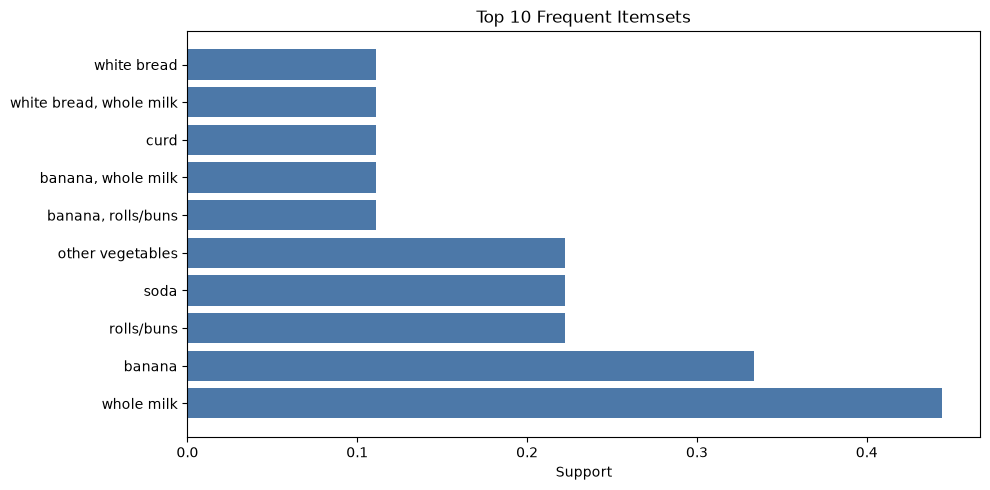

Grafik frequent itemsets selesai


In [27]:
# Visualisasi
def fmt_items(items):
    return ", ".join(sorted([str(x) for x in items]))

# Pastikan data dan hasil tersedia, walaupun sel sebelumnya belum dijalankan
if "frequent" not in globals() or "hasil" not in globals():
    data = pd.read_csv("Groceries_dataset.csv")

    transaksi = (
        data.groupby(["Member_number", "Date"])["itemDescription"]
        .apply(list)
        .tolist()
    )

    te = TransactionEncoder()
    encoded = te.fit(transaksi).transform(transaksi)
    df = pd.DataFrame(encoded, columns=te.columns_)

    frequent = fpgrowth(df, min_support=0.03, use_colnames=True)
    rules = association_rules(frequent, metric="confidence", min_threshold=0.5)
    hasil = rules[["antecedents", "consequents", "support", "confidence", "lift"]]

# Visualisasi 1: Top 10 frequent itemsets
freq_plot = frequent.head(10).copy()
freq_plot["itemsets_str"] = freq_plot["itemsets"].apply(fmt_items)
freq_plot = freq_plot.sort_values("support", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(freq_plot["itemsets_str"], freq_plot["support"], color="#4C78A8")
plt.gca().invert_yaxis()
plt.xlabel("Support")
plt.title("Top 10 Frequent Itemsets")
plt.tight_layout()
plt.savefig("frequent_itemsets.png", dpi=300, bbox_inches="tight")
plt.show()

print("Grafik frequent itemsets selesai")

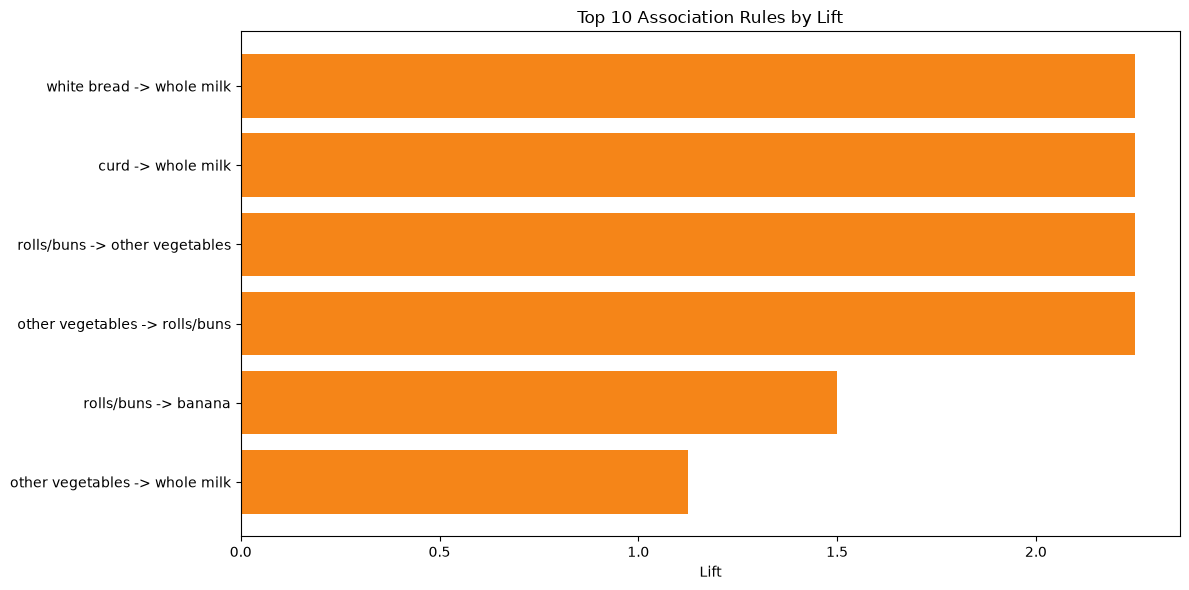

Grafik association rules selesai


In [28]:
def fmt_items(items):
    return ", ".join(sorted([str(x) for x in items]))

# Pastikan data dan hasil tersedia, walaupun sel sebelumnya belum dijalankan
if "frequent" not in globals() or "hasil" not in globals():
    data = pd.read_csv("Groceries_dataset.csv")

    transaksi = (
        data.groupby(["Member_number", "Date"])["itemDescription"]
        .apply(list)
        .tolist()
    )

    te = TransactionEncoder()
    encoded = te.fit(transaksi).transform(transaksi)
    df = pd.DataFrame(encoded, columns=te.columns_)

    frequent = fpgrowth(df, min_support=0.03, use_colnames=True)
    rules = association_rules(frequent, metric="confidence", min_threshold=0.5)
    hasil = rules[["antecedents", "consequents", "support", "confidence", "lift"]]

# Visualisasi 2: Top 10 association rules berdasarkan lift
rule_plot = hasil.sort_values(["lift", "confidence"], ascending=False).head(10).copy()
rule_plot["antecedent_str"] = rule_plot["antecedents"].apply(fmt_items)
rule_plot["consequent_str"] = rule_plot["consequents"].apply(fmt_items)
rule_plot["rule"] = rule_plot["antecedent_str"] + " -> " + rule_plot["consequent_str"]

plt.figure(figsize=(12, 6))
plt.barh(rule_plot["rule"], rule_plot["lift"], color="#F58518")
plt.gca().invert_yaxis()
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
plt.savefig("association_rules.png", dpi=300, bbox_inches="tight")
plt.show()

print("Grafik association rules selesai")